# PHASE 2: DATA ANALYTICS, VISUALIZATION 
### i. Perform summary analytics to highlight important information from the prepared dataset. 



*1. Average Carbon Emissions by Car Maker* <br>
Luxury and high-performance vehicle manufacturers, such as Aston Martin (359.0 g/km), Bently (348.6 g/km), and Maserati (347.0 g/km), always have the highest average emissions, according to one such analysis of average carbon dioxide (CO2) emissions by manufacturer. These manufacturers are widely renowned for producing vehicles with powerful engines and plenty of horsepower, and such vehicles naturally imply high fuel usage and high pollution. Hybrid and economy-oriented automakers, such as Honda and Toyota, have much lower average emissions consistently, at 178.5 g/km for Honda and 174.3 g/km for Toyota. The study shows the significant role car design philosophy and brand positioning play in environmental performance. Power- and luxury-biased automakers compromise on fuel efficiency, increasing greenhouse emissions. This is yet another piece of evidence in support of regulation of emission standards for high-emission market niches and sustainable vehicle design.

*2. Average Carbon Emissions by Car Model* <br>
High-performance and luxury cars always have the highest average CO2 emissions when ranked by model. An example is the Bentley Mulsanne with a staggering 437.0 g/km, followed by the Audi R8 with 376.5 g/km, and the Aston Martin Vanquish with 359.0 g/km. These cars focus on performance, usually at the cost of fuel efficiency. Quite the opposite are cars that are engineered to be more fuel-efficient, with the Toyota Corolla at 169.5 g/km and the Honda Civic with 167.3 g/km, having much lower emissions. This kind of insight into specific models becomes invaluable for policymakers and consumers alike. It highlights the fact that emissions can vary hugely within an automobile brand, depending on the model and the type of engine. For policies to reduce emissions to be effective, they need to specifically address high-emission models but also look at the brands as a whole.

*3. Average Carbon Emissions by Engine Size* <br>
The relationship between engine size and CO2 emissions becomes prominently clear: bigger engines use more fuel per cycle, thereby increasing emissions. Cars with engines over 4.0L have the highest average emissions at 304.58 g/km, whereas those with engine capacities less than 1.5L have the lowest at 165.73 g/km. In addition, mid-range engine capacities, between 2.5-3.0L and 3.0-4.0L, also feature highly in emissions, with averages of 270.29 g/km and 267.54 g/km, respectively. This trend is repeated across fuel types consistently, reinforcing the idea that engine size is a major driver of emission rates. The information derived from this data is extremely useful to consumers considering their next purchase, as well as to government bodies developing automobile taxation policies or emission standards. Providing incentives to encourage the purchase of smaller engine cars or the use of downsizing technologies, like turbocharging, would result in a dramatic decrease in emissions across the whole fleet.

*4. Average Carbon Emissions by Vehicle Class* <br>
The vehicle class is an essential indicator of emissions, with bigger vehicles having higher CO2.  SUVs (Standard) have the highest mean emissions of 294.24 g/km due to the bigger size and powerful engines. Subcompact cars also have high emissions of 282.32 g/km, and lower car classes, such as compact and station wagons, have lower emissions of 167.14 g/km and 174.5 g/km. This lends support to the fact that the weight and size of the vehicle are directly proportional to carbon output. In nations like Malaysia, where the use of cars is on the increase and traffic in cities is on the rise, promoting lower and fuel-efficient vehicle classes may be an effective way of curbing urban pollution and achieving environmental targets.

*5. Average Emissions by Transmission Type* <br>
Transmission type is also another determinant of car emissions. The analysis shows that automatic transmissions (e.g., A7, AM6) produce more CO2 emissions than manual transmissions. The highest emission rate is found for cars with A7 (automatic, 7 gears) with an average emission of 345.0 g/km. Manual cars like M5 have significantly lower emissions, averaging 174.24 g/km. Automatic transmissions, which are typically fitted in larger or sports cars, are associated with higher emissions due to inefficient fuel consumption. Manual transmissions, on the other hand, are more common in smaller cars, which are fuel-efficient with low emissions.

### ii. Perform appropriate machine learning method to classify / cluster the car maker / car model according to their carbon emissions using machine learning

In this analysis, we will classify cars into their car makers using features like CO2 emissions, engine size, fuel consumption, cylinders, and transmission type. To do this, we'll use the Random Forest algorithm, a machine learning technique that combines several decision trees for better accuracy. We will split the data into 80% for training and 20% for testing. By training the model with these features, we'll predict the car maker and assess the model's performance using accuracy and the confusion matrix to see how well it performs and which features are most important.

Accuracy of Car Maker Classification: 99.62%


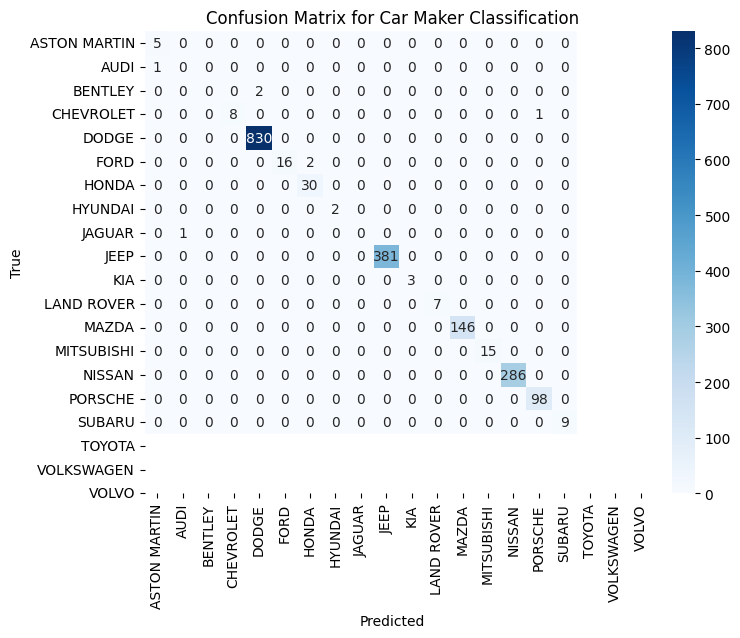

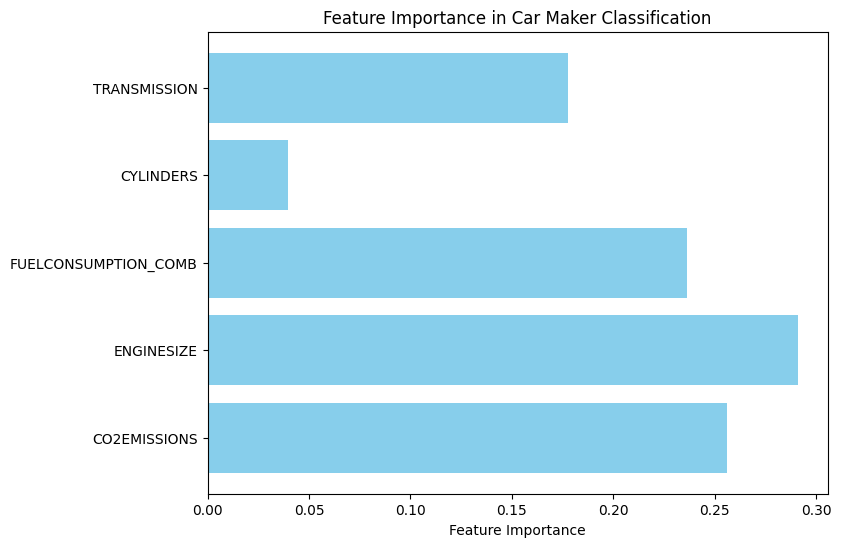

In [3]:
# Import libraries
# pandas (pd) = for handling table-like data.
# numpy (np) = for doing math and working with arrays.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the final dataset
final_data_cleaned = pd.read_csv("cleaned_merged_car_data_2.csv")

# Select features (CO2 emissions, engine size, fuel consumption, cylinders, and transmission) for classification
X = final_data_cleaned[['CO2EMISSIONS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CYLINDERS', 'TRANSMISSION']]  # Features (input variables)
y = final_data_cleaned['MAKE']  # Target variable (car maker)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the classifier's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Car Maker Classification: {accuracy * 100:.2f}%")

# Confusion matrix to see detailed performance
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.title('Confusion Matrix for Car Maker Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Feature importance: To see which features are important for classification
feature_importances = rf_classifier.feature_importances_
features = ['CO2EMISSIONS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CYLINDERS', 'TRANSMISSION']

# Plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Car Maker Classification')
plt.show()


The first figure shows the confusion matrix, which illustrates how well the Random Forest classifier predicted the car makers based on the selected features. The diagonal elements represent the correct predictions, where the true and predicted labels match. For example, Dodge has 830 correct predictions, Hyundai has 381, Mazda had 146, and Nissan has 286. The off-diagonal elements show misclassifications, such as Audi being misclassified as ASTON MARTIN (1 time), Jaguar as Audi (1 time), Ford as Honda (2 times), and Chevrolet as Porsche (1 time). Even though got these errors, the model achieves a high accuracy of 99.62%, indicating strong performance overall for this dataset.

The second figure shows the feature importance, helping us understand which features were most influential in predicting the car maker. Engine Size had the highest importance, followed by CO2 Emissions and Fuel Consumption. These three features are crucial for the classification task, with Engine Size being the most significant. On the other hand, Transmission contributed less, and Cylinders had the smallest impact, making it the least important feature. In summary, Engine Size, CO2 Emissions, and Fuel Consumption were key drivers of the model's predictions, while Transmission and Cylinders played a smaller role.